# PathMNIST Data Expansion Scaling Comparison

This notebook summarizes the PathMNIST reproduction results in a Figure 4-style scaling plot.

- Dataset: PathMNIST, 900 train images and 7,180 test images
- Classifier: ResNet-50 trained from scratch
- Seeds: 1, 2, 3
- Compared methods: Original-only, Naive Stable Diffusion, DistDiff

The notebook reads `results.yaml` files from the current `model/` checkpoint directory, computes the mean and population standard deviation used by `parse_logs.py`, and saves the plot/table under `debug/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd()
if ROOT.name == "debug":
    ROOT = ROOT.parent

OUT_DIR = ROOT / "debug"
OUT_DIR.mkdir(exist_ok=True)

RATIOS = [0, 1, 2, 5, 10]
SEEDS = [1, 2, 3]

print(f"Using model root: {ROOT}")

Using model root: /workspace/jhoh/03-Class/CV/project/model


In [2]:
def read_best_accuracy(path: Path) -> float:
    with path.open("r") as f:
        data = yaml.safe_load(f)
    return float(data["best_accuracy"])


def result_path(method: str, ratio: int, seed: int) -> Path:
    if method == "Original-only":
        return ROOT / "checkpoint" / "pathmnist" / "resnet50_unpretrained_lr0.1" / f"seed{seed}" / "results.yaml"

    prefix = {
        "Naive SD": "sd_batch",
        "DistDiff": "distdiff_batch",
    }[method]
    return (
        ROOT
        / "checkpoint"
        / "pathmnist"
        / "resnet50_unpretrained_save"
        / f"{prefix}_{ratio}x_lr0.1"
        / f"seed{seed}"
        / "results.yaml"
    )


def collect_seed_scores(method: str, ratio: int = 0) -> list[float]:
    scores = []
    for seed in SEEDS:
        path = result_path(method, ratio, seed)
        if not path.exists():
            raise FileNotFoundError(path)
        scores.append(read_best_accuracy(path))
    return scores


def summarize(scores: list[float]) -> tuple[float, float]:
    values = np.array(scores, dtype=float)
    return float(values.mean()), float(values.std(ddof=0))


rows = []

original_scores = collect_seed_scores("Original-only", 0)
mean, std = summarize(original_scores)
rows.append({
    "Setting": "Original-only",
    "Ratio": 0,
    "Seed1": original_scores[0],
    "Seed2": original_scores[1],
    "Seed3": original_scores[2],
    "Mean": mean,
    "Std": std,
})

for method in ["Naive SD", "DistDiff"]:
    for ratio in [1, 2, 5, 10]:
        scores = collect_seed_scores(method, ratio)
        mean, std = summarize(scores)
        rows.append({
            "Setting": f"{method} {ratio}x",
            "Method": method,
            "Ratio": ratio,
            "Seed1": scores[0],
            "Seed2": scores[1],
            "Seed3": scores[2],
            "Mean": mean,
            "Std": std,
        })

df = pd.DataFrame(rows)
df["Method"] = df["Method"].fillna("Original-only")
df["Mean +/- Std"] = df.apply(lambda r: f"{r['Mean']:.2f} +/- {r['Std']:.2f}", axis=1)

display_cols = ["Setting", "Seed1", "Seed2", "Seed3", "Mean +/- Std"]
display_df = df[display_cols].copy()
for col in ["Seed1", "Seed2", "Seed3"]:
    display_df[col] = display_df[col].map(lambda v: f"{v:.2f}")

display_df

,Setting,Seed1,Seed2,Seed3,Mean +/- Std
0,Original-only,73.20,75.77,73.45,74.14 +/- 1.15
1,Naive SD 1x,82.12,80.32,81.96,81.47 +/- 0.81
2,Naive SD 2x,82.62,82.55,82.12,82.43 +/- 0.22
3,Naive SD 5x,82.65,82.40,81.95,82.33 +/- 0.29
4,Naive SD 10x,82.87,84.05,83.18,83.37 +/- 0.50
5,DistDiff 1x,80.29,82.31,80.67,81.09 +/- 0.88
6,DistDiff 2x,81.31,79.97,81.55,80.94 +/- 0.69
7,DistDiff 5x,81.36,82.65,83.59,82.53 +/- 0.91
8,DistDiff 10x,81.53,82.17,83.48,82.40 +/- 0.81


In [3]:
csv_path = OUT_DIR / "pathmnist_scale_results.csv"
df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

Saved: /workspace/jhoh/03-Class/CV/project/model/debug/pathmnist_scale_results.csv


Saved: /workspace/jhoh/03-Class/CV/project/model/debug/pathmnist_figure4_scale_data_size.png
Saved: /workspace/jhoh/03-Class/CV/project/model/debug/pathmnist_figure4_scale_data_size.pdf


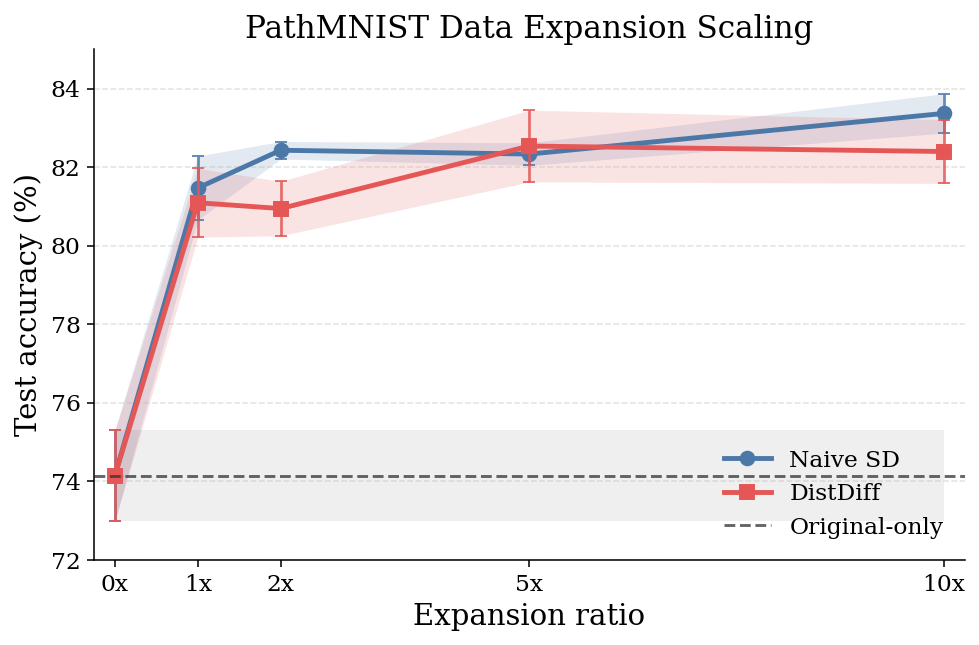

In [4]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 140,
})

baseline_mean = df.loc[df["Setting"] == "Original-only", "Mean"].item()
baseline_std = df.loc[df["Setting"] == "Original-only", "Std"].item()

plot_data = {}
for method in ["Naive SD", "DistDiff"]:
    method_df = df[df["Method"] == method].sort_values("Ratio")
    x = [0] + method_df["Ratio"].tolist()
    y = [baseline_mean] + method_df["Mean"].tolist()
    err = [baseline_std] + method_df["Std"].tolist()
    plot_data[method] = (np.array(x), np.array(y), np.array(err))

fig, ax = plt.subplots(figsize=(7.2, 4.8))

colors = {
    "Naive SD": "#4C78A8",
    "DistDiff": "#E45756",
}
markers = {
    "Naive SD": "o",
    "DistDiff": "s",
}

for method in ["Naive SD", "DistDiff"]:
    x, y, err = plot_data[method]
    ax.plot(
        x,
        y,
        marker=markers[method],
        markersize=7,
        linewidth=2.5,
        color=colors[method],
        label=method,
    )
    ax.fill_between(x, y - err, y + err, color=colors[method], alpha=0.16, linewidth=0)
    ax.errorbar(x, y, yerr=err, fmt="none", ecolor=colors[method], elinewidth=1.4, capsize=3, alpha=0.85)

ax.axhline(baseline_mean, color="#333333", linestyle="--", linewidth=1.5, alpha=0.75, label="Original-only")
ax.fill_between(
    [min(RATIOS), max(RATIOS)],
    baseline_mean - baseline_std,
    baseline_mean + baseline_std,
    color="#333333",
    alpha=0.08,
    linewidth=0,
)

ax.set_title("PathMNIST Data Expansion Scaling")
ax.set_xlabel("Expansion ratio")
ax.set_ylabel("Test accuracy (%)")
ax.set_xticks(RATIOS)
ax.set_xticklabels([f"{r}x" for r in RATIOS])
ax.set_xlim(-0.25, 10.25)
ax.set_ylim(72, 85)
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()

png_path = OUT_DIR / "pathmnist_figure4_scale_data_size.png"
pdf_path = OUT_DIR / "pathmnist_figure4_scale_data_size.pdf"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
plt.show()

In [5]:
summary = df[["Setting", "Seed1", "Seed2", "Seed3", "Mean", "Std"]].copy()
for col in ["Seed1", "Seed2", "Seed3", "Mean", "Std"]:
    summary[col] = summary[col].map(lambda v: f"{v:.2f}")
summary

,Setting,Seed1,Seed2,Seed3,Mean,Std
0,Original-only,73.20,75.77,73.45,74.14,1.15
1,Naive SD 1x,82.12,80.32,81.96,81.47,0.81
2,Naive SD 2x,82.62,82.55,82.12,82.43,0.22
3,Naive SD 5x,82.65,82.40,81.95,82.33,0.29
4,Naive SD 10x,82.87,84.05,83.18,83.37,0.50
5,DistDiff 1x,80.29,82.31,80.67,81.09,0.88
6,DistDiff 2x,81.31,79.97,81.55,80.94,0.69
7,DistDiff 5x,81.36,82.65,83.59,82.53,0.91
8,DistDiff 10x,81.53,82.17,83.48,82.40,0.81
